
Reading: Test 1
2sub-500m-20cl
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_1/

Reading: Test 2
2sub-500m-75cl
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_2/

Reading: Test 3
2sub-500m-125cl
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/

Reading: Test 4
2sub-50m-125cl
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_4/

Reading: Test 5
2sub-1000m-125cl
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_5/

Reading: Test 6
5sub-50m-125cl
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Sno

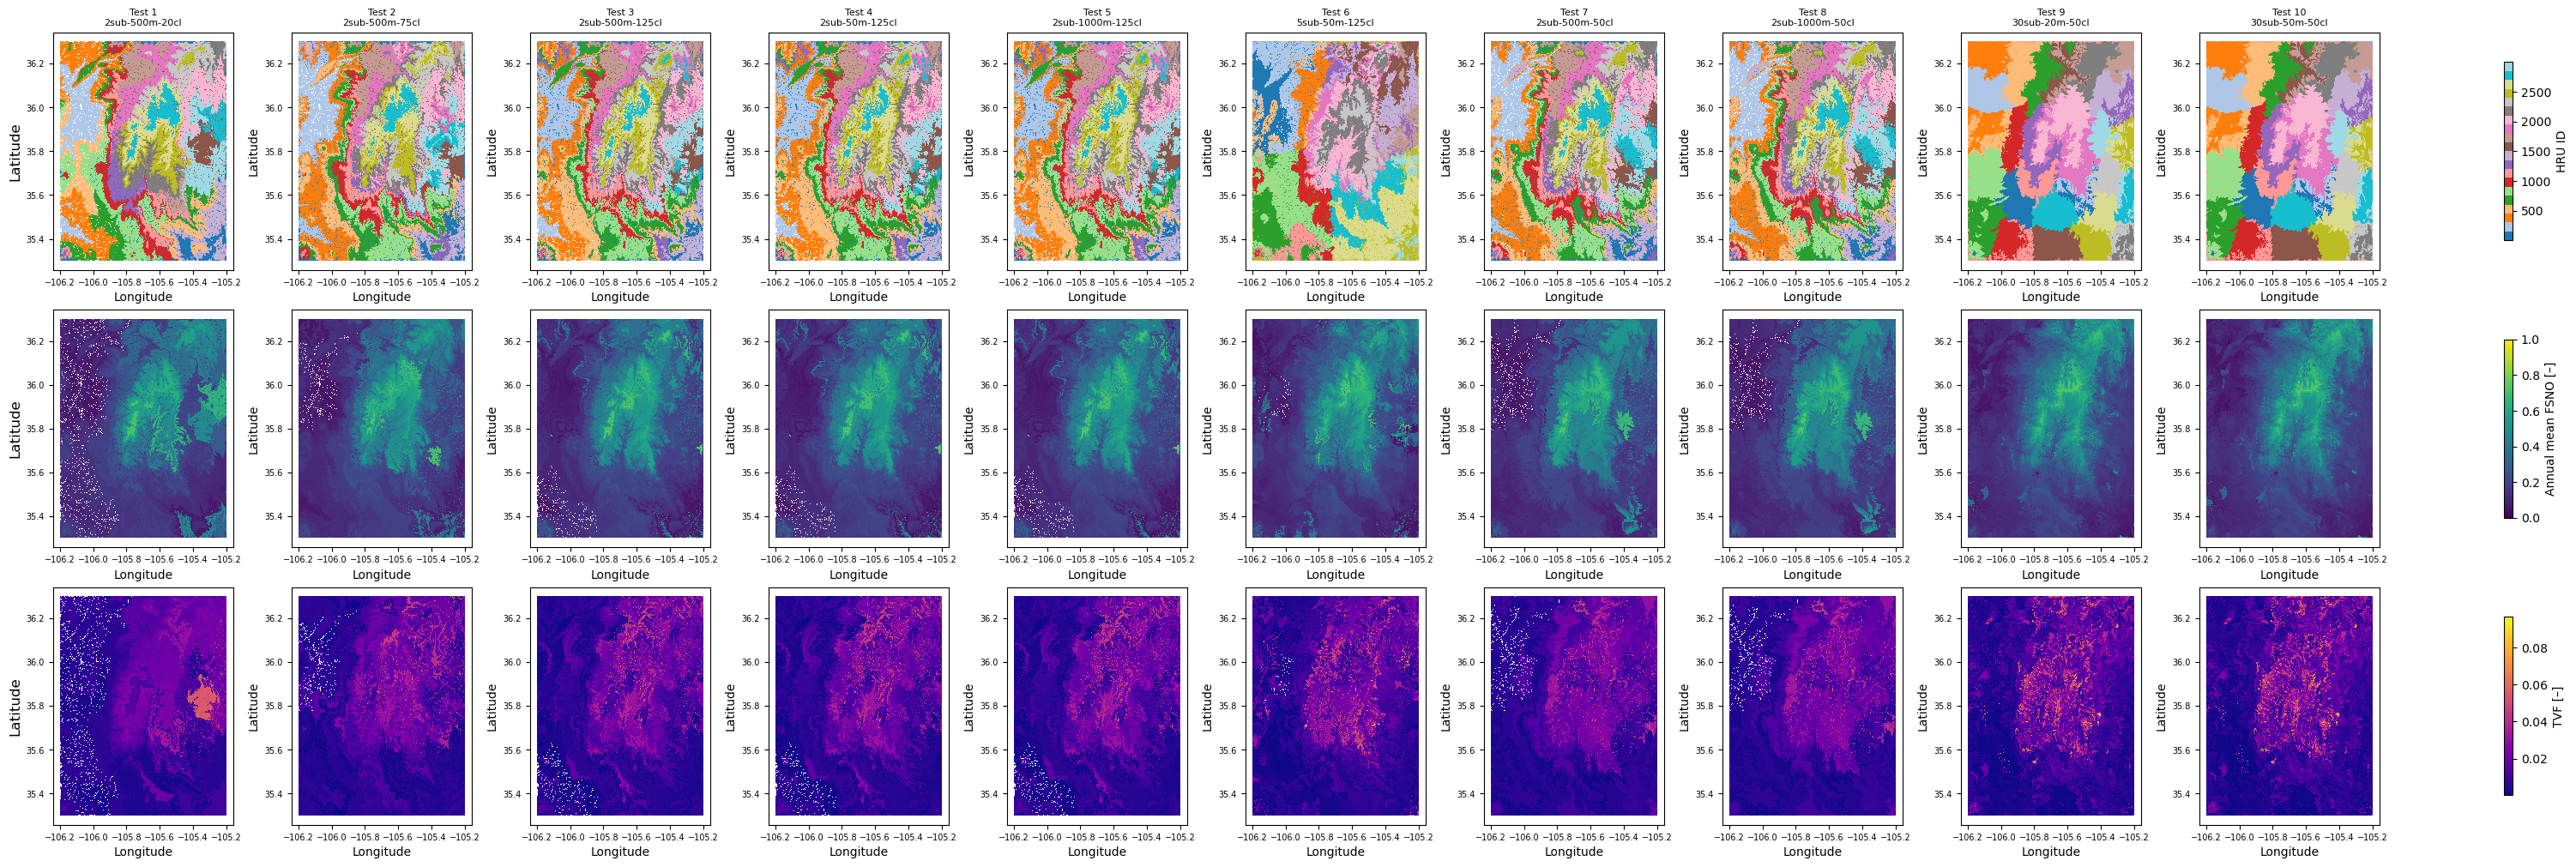

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/septiles_tests_HRU_FSNO_TVF/septiles_tests_HRU_FSNO_TVF_all_cids.png


In [1]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Test 1\n2sub-500m-20cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_1/",
    "Test 2\n2sub-500m-75cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_2/",
    "Test 3\n2sub-500m-125cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/",
    "Test 4\n2sub-50m-125cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_4/",
    "Test 5\n2sub-1000m-125cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_5/",
    "Test 6\n5sub-50m-125cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_6/",
    "Test 7\n2sub-500m-50cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_7/",
    "Test 8\n2sub-1000m-50cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_8/",
    "Test 9\n30sub-20m-50cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_9/",
    "Test 10\n30sub-50m-50cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_10/",
}

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/septiles_tests_HRU_FSNO_TVF"
os.makedirs(outputdir, exist_ok=True)

buffer = 250


def read_fsno(path):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables["fsno"][:])
    fp.close()
    return data


def read_param(path, paramname):
    fp = nc.Dataset(path + "/1/input_file.nc")
    data = np.array(fp.groups["parameters"].variables[paramname][:])
    fp.close()
    return data


def place_data_all_cids(tmp, model_hru, hrus, cids):
    out = np.copy(tmp)

    model_hru = np.asarray(model_hru).squeeze()
    nhru = len(model_hru)

    valid = (
        (cids > 0) &
        (hrus > 0) &
        (hrus <= nhru)
    )

    hru_idx = hrus[valid].astype(int) - 1
    out[valid] = model_hru[hru_idx]

    return out


def clean_and_crop(arr):
    arr = np.where(arr == -9999.0, np.nan, arr)

    return arr[
        buffer:arr.shape[0] - buffer + 1,
        buffer:arr.shape[1] - buffer + 1
    ]


def get_maps(path):
    hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

    tmp = np.full(hrus.shape, -9999.0)

    fsno = read_fsno(path)
    fsno_mean_hru = np.nanmean(fsno, axis=0)
    fsno_mean_hru = np.asarray(fsno_mean_hru).squeeze()
    fsno_map = place_data_all_cids(tmp, fsno_mean_hru, hrus, cids)

    tvf_hru = read_param(path, "tvf")
    tvf_hru = np.asarray(tvf_hru).squeeze()
    tvf_map = place_data_all_cids(tmp, tvf_hru, hrus, cids)

    hru_map = np.copy(hrus)
    hru_map = np.where((cids > 0) & (hrus > 0), hru_map, np.nan)

    return (
        clean_and_crop(hru_map),
        clean_and_crop(fsno_map),
        clean_and_crop(tvf_map)
    )


first_valid_path = None
for p in runs.values():
    if os.path.exists(p + "postprocess/hrus.vrt"):
        first_valid_path = p
        break

if first_valid_path is None:
    raise RuntimeError("No valid run with postprocess/hrus.vrt was found.")

meta = gdal_tools.retrieve_metadata(first_valid_path + "postprocess/hrus.vrt")

coord_xx0 = np.linspace(meta["minx"], meta["maxx"], meta["nx"])
coord_yy0 = np.linspace(meta["miny"], meta["maxy"], meta["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]


hru_maps = []
fsno_maps = []
tvf_maps = []
labels = []

for label, path in runs.items():
    print("\nReading:", label)
    print("Path:", path)

    if not os.path.exists(path):
        print("Missing path, skipping:", path)
        continue

    hru_file = path + "postprocess/hrus.vrt"
    cid_file = path + "postprocess/cids.vrt"
    out_file = path + "/output_data/1/2016-01-01.nc"
    inp_file = path + "/1/input_file.nc"

    if not os.path.exists(hru_file):
        print("Missing HRU file, skipping:", hru_file)
        continue

    if not os.path.exists(cid_file):
        print("Missing CID file, skipping:", cid_file)
        continue

    if not os.path.exists(out_file):
        print("Missing output file, skipping:", out_file)
        continue

    if not os.path.exists(inp_file):
        print("Missing input file, skipping:", inp_file)
        continue

    hru_map, fsno_map, tvf_map = get_maps(path)

    hru_maps.append(hru_map)
    fsno_maps.append(fsno_map)
    tvf_maps.append(tvf_map)
    labels.append(label)


if len(labels) == 0:
    raise RuntimeError("No valid runs found. Check paths and filenames.")


fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

tvf_min = np.nanmin([np.nanmin(m) for m in tvf_maps])
tvf_max = np.nanmax([np.nanmax(m) for m in tvf_maps])
tvf_norm = colors.Normalize(vmin=tvf_min, vmax=tvf_max)

ncols = len(labels)

fig, axes = plt.subplots(
    3,
    ncols,
    figsize=(3.0 * ncols, 10),
    constrained_layout=True
)

if ncols == 1:
    axes = axes.reshape(3, 1)


hru_cmap = plt.cm.tab20.copy()
hru_cmap.set_bad(color="white")

fsno_cmap = plt.cm.viridis.copy()
fsno_cmap.set_bad(color="white")

tvf_cmap = plt.cm.plasma.copy()
tvf_cmap.set_bad(color="white")


for col in range(ncols):

    im0 = axes[0, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(hru_maps[col]),
        cmap=hru_cmap,
        shading="auto"
    )
    axes[0, col].set_title(labels[col], fontsize=8)

    im1 = axes[1, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(fsno_maps[col]),
        cmap=fsno_cmap,
        norm=fsno_norm,
        shading="auto"
    )

    im2 = axes[2, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(tvf_maps[col]),
        cmap=tvf_cmap,
        norm=tvf_norm,
        shading="auto"
    )


axes[0, 0].set_ylabel("HRU distribution", fontsize=12)
axes[1, 0].set_ylabel("Annual mean FSNO", fontsize=12)
axes[2, 0].set_ylabel("Terrain View Factor", fontsize=12)

for i in range(3):
    for j in range(ncols):
        axes[i, j].set_xlabel("Longitude")
        axes[i, j].set_ylabel("Latitude")
        axes[i, j].tick_params(labelsize=7)


cbar0 = fig.colorbar(im0, ax=axes[0, :], shrink=0.75)
cbar0.set_label("HRU ID")

cbar1 = fig.colorbar(im1, ax=axes[1, :], shrink=0.75)
cbar1.set_label("Annual mean FSNO [–]")

cbar2 = fig.colorbar(im2, ax=axes[2, :], shrink=0.75)
cbar2.set_label("TVF [–]")


outfile = os.path.join(outputdir, "septiles_tests_HRU_FSNO_TVF_all_cids.png")

plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)


Reading: Test 1
2sub-500m-20cl
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_1/

Reading: Test 2
2sub-500m-75cl
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_2/

Reading: Test 3
2sub-500m-125cl
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/

Reading: Test 4
2sub-50m-125cl
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_4/

Reading: Test 5
2sub-1000m-125cl
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_5/

Reading: Test 6
5sub-50m-125cl
Path: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations/MSWX_3h_Sno

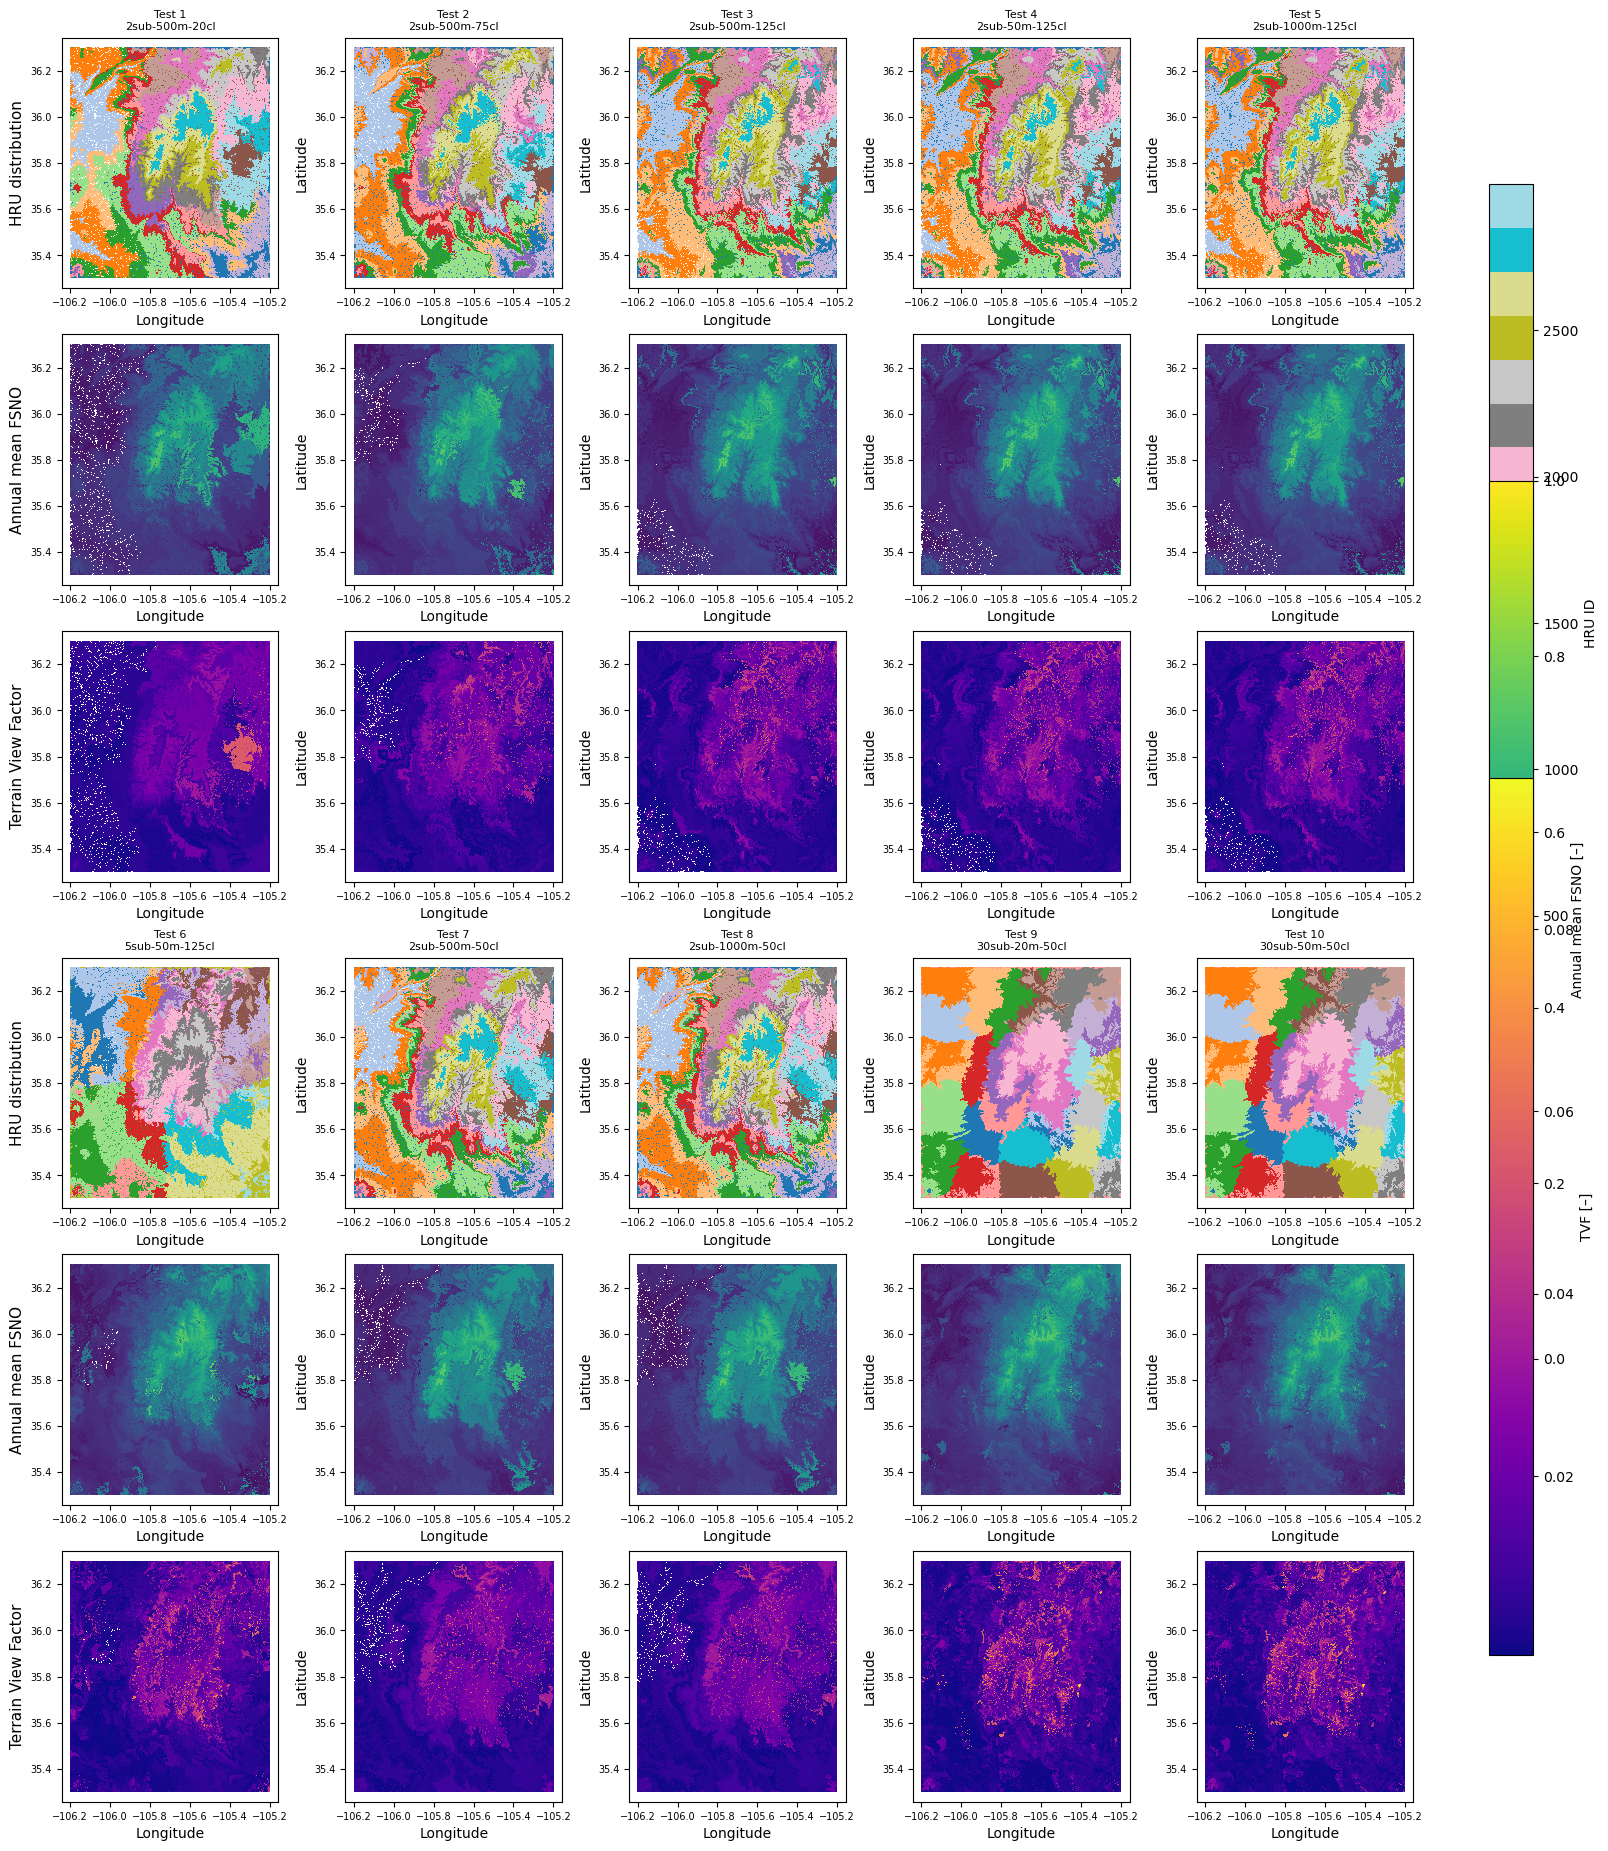

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/septiles_tests_HRU_FSNO_TVF/septiles_tests_HRU_FSNO_TVF_5_per_row.png


In [2]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Test 1\n2sub-500m-20cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_1/",
    "Test 2\n2sub-500m-75cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_2/",
    "Test 3\n2sub-500m-125cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/",
    "Test 4\n2sub-50m-125cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_4/",
    "Test 5\n2sub-1000m-125cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_5/",
    "Test 6\n5sub-50m-125cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_6/",
    "Test 7\n2sub-500m-50cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_7/",
    "Test 8\n2sub-1000m-50cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_8/",
    "Test 9\n30sub-20m-50cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_9/",
    "Test 10\n30sub-50m-50cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_10/",
}

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/septiles_tests_HRU_FSNO_TVF"
os.makedirs(outputdir, exist_ok=True)

buffer = 250
plots_per_row = 5


def read_fsno(path):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables["fsno"][:])
    fp.close()
    return data


def read_param(path, paramname):
    fp = nc.Dataset(path + "/1/input_file.nc")
    data = np.array(fp.groups["parameters"].variables[paramname][:])
    fp.close()
    return data


def place_data_all_cids(tmp, model_hru, hrus, cids):
    out = np.copy(tmp)

    model_hru = np.asarray(model_hru).squeeze()
    nhru = len(model_hru)

    valid = (
        (cids > 0) &
        (hrus > 0) &
        (hrus <= nhru)
    )

    hru_idx = hrus[valid].astype(int) - 1
    out[valid] = model_hru[hru_idx]

    return out


def clean_and_crop(arr):
    arr = np.where(arr == -9999.0, np.nan, arr)

    return arr[
        buffer:arr.shape[0] - buffer + 1,
        buffer:arr.shape[1] - buffer + 1
    ]


def get_maps(path):
    hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

    tmp = np.full(hrus.shape, -9999.0)

    fsno = read_fsno(path)
    fsno_mean_hru = np.nanmean(fsno, axis=0)
    fsno_mean_hru = np.asarray(fsno_mean_hru).squeeze()
    fsno_map = place_data_all_cids(tmp, fsno_mean_hru, hrus, cids)

    tvf_hru = read_param(path, "tvf")
    tvf_hru = np.asarray(tvf_hru).squeeze()
    tvf_map = place_data_all_cids(tmp, tvf_hru, hrus, cids)

    hru_map = np.copy(hrus)
    hru_map = np.where((cids > 0) & (hrus > 0), hru_map, np.nan)

    return (
        clean_and_crop(hru_map),
        clean_and_crop(fsno_map),
        clean_and_crop(tvf_map)
    )


first_valid_path = None
for p in runs.values():
    if os.path.exists(p + "postprocess/hrus.vrt"):
        first_valid_path = p
        break

if first_valid_path is None:
    raise RuntimeError("No valid run with postprocess/hrus.vrt was found.")

meta = gdal_tools.retrieve_metadata(first_valid_path + "postprocess/hrus.vrt")

coord_xx0 = np.linspace(meta["minx"], meta["maxx"], meta["nx"])
coord_yy0 = np.linspace(meta["miny"], meta["maxy"], meta["ny"])

coords_x = coord_xx0[buffer:len(coord_xx0) - buffer + 1]
coords_y = coord_yy0[buffer:len(coord_yy0) - buffer + 1]


hru_maps = []
fsno_maps = []
tvf_maps = []
labels = []

for label, path in runs.items():
    print("\nReading:", label)
    print("Path:", path)

    if not os.path.exists(path):
        print("Missing path, skipping:", path)
        continue

    hru_file = path + "postprocess/hrus.vrt"
    cid_file = path + "postprocess/cids.vrt"
    out_file = path + "/output_data/1/2016-01-01.nc"
    inp_file = path + "/1/input_file.nc"

    if not os.path.exists(hru_file):
        print("Missing HRU file, skipping:", hru_file)
        continue

    if not os.path.exists(cid_file):
        print("Missing CID file, skipping:", cid_file)
        continue

    if not os.path.exists(out_file):
        print("Missing output file, skipping:", out_file)
        continue

    if not os.path.exists(inp_file):
        print("Missing input file, skipping:", inp_file)
        continue

    hru_map, fsno_map, tvf_map = get_maps(path)

    hru_maps.append(hru_map)
    fsno_maps.append(fsno_map)
    tvf_maps.append(tvf_map)
    labels.append(label)


if len(labels) == 0:
    raise RuntimeError("No valid runs found. Check paths and filenames.")


fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

tvf_min = np.nanmin([np.nanmin(m) for m in tvf_maps])
tvf_max = np.nanmax([np.nanmax(m) for m in tvf_maps])
tvf_norm = colors.Normalize(vmin=tvf_min, vmax=tvf_max)


n_runs = len(labels)
ncol_panels = plots_per_row
nrow_panels = int(np.ceil(n_runs / plots_per_row))

fig, axes = plt.subplots(
    3 * nrow_panels,
    ncol_panels,
    figsize=(3.2 * ncol_panels, 9.2 * nrow_panels),
    constrained_layout=True
)

axes = np.atleast_2d(axes)


hru_cmap = plt.cm.tab20.copy()
hru_cmap.set_bad(color="white")

fsno_cmap = plt.cm.viridis.copy()
fsno_cmap.set_bad(color="white")

tvf_cmap = plt.cm.plasma.copy()
tvf_cmap.set_bad(color="white")


for idx in range(n_runs):

    row_block = idx // plots_per_row
    col = idx % plots_per_row

    r0 = row_block * 3
    r1 = r0 + 1
    r2 = r0 + 2

    im0 = axes[r0, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(hru_maps[idx]),
        cmap=hru_cmap,
        shading="auto"
    )
    axes[r0, col].set_title(labels[idx], fontsize=8)

    im1 = axes[r1, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(fsno_maps[idx]),
        cmap=fsno_cmap,
        norm=fsno_norm,
        shading="auto"
    )

    im2 = axes[r2, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(tvf_maps[idx]),
        cmap=tvf_cmap,
        norm=tvf_norm,
        shading="auto"
    )

    for rr in [r0, r1, r2]:
        axes[rr, col].set_xlabel("Longitude")
        axes[rr, col].set_ylabel("Latitude")
        axes[rr, col].tick_params(labelsize=7)


# Turn off unused panels if number of runs is not multiple of 5
total_panels = nrow_panels * plots_per_row
for idx in range(n_runs, total_panels):
    row_block = idx // plots_per_row
    col = idx % plots_per_row

    r0 = row_block * 3
    r1 = r0 + 1
    r2 = r0 + 2

    axes[r0, col].axis("off")
    axes[r1, col].axis("off")
    axes[r2, col].axis("off")


for block in range(nrow_panels):
    rr = block * 3

    axes[rr, 0].set_ylabel("HRU distribution", fontsize=11)
    axes[rr + 1, 0].set_ylabel("Annual mean FSNO", fontsize=11)
    axes[rr + 2, 0].set_ylabel("Terrain View Factor", fontsize=11)


cbar0 = fig.colorbar(im0, ax=axes[0::3, :], shrink=0.75)
cbar0.set_label("HRU ID")

cbar1 = fig.colorbar(im1, ax=axes[1::3, :], shrink=0.75)
cbar1.set_label("Annual mean FSNO [–]")

cbar2 = fig.colorbar(im2, ax=axes[2::3, :], shrink=0.75)
cbar2.set_label("TVF [–]")


outfile = os.path.join(outputdir, "septiles_tests_HRU_FSNO_TVF_5_per_row.png")

plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", outfile)


Reading: Test 1
2sub-500m-20cl

Reading: Test 2
2sub-500m-75cl

Reading: Test 3
2sub-500m-125cl

Reading: Test 4
2sub-50m-125cl

Reading: Test 5
2sub-1000m-125cl

Reading: Test 6
5sub-50m-125cl

Reading: Test 7
2sub-500m-50cl

Reading: Test 8
2sub-1000m-50cl

Reading: Test 9
30sub-20m-50cl

Reading: Test 10
30sub-50m-50cl


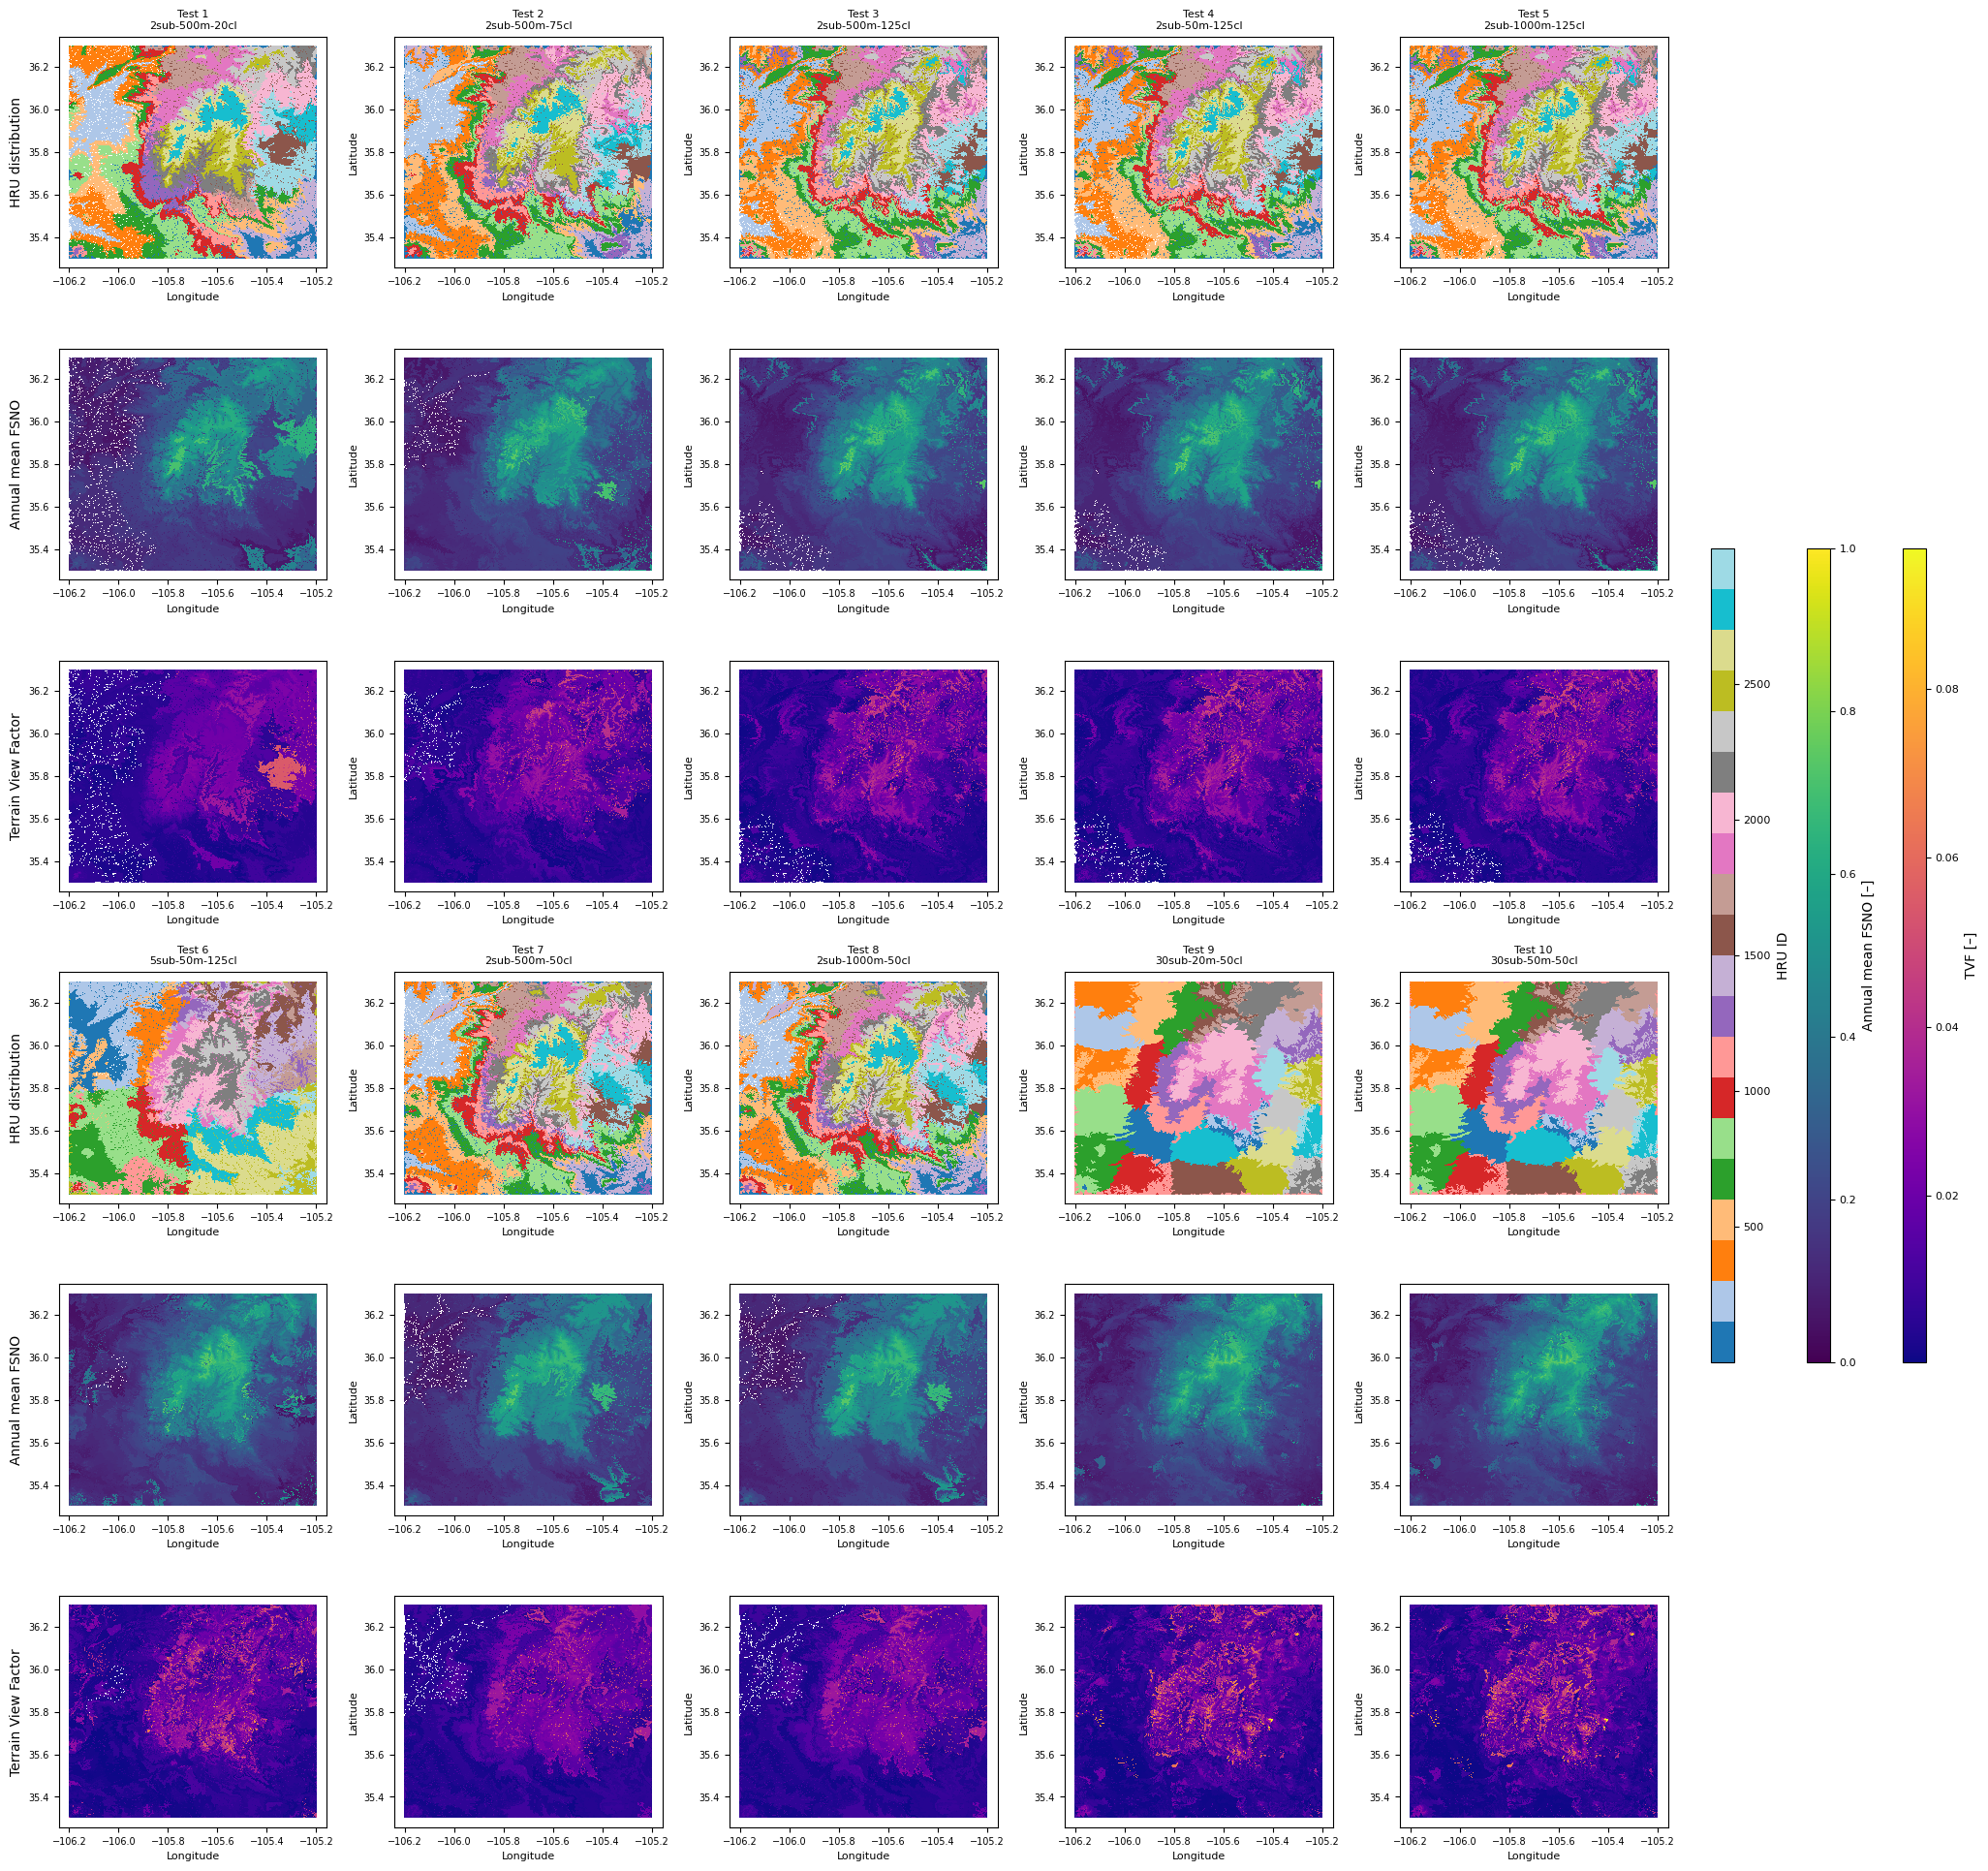


Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/septiles_tests_HRU_FSNO_TVF/septiles_tests_HRU_FSNO_TVF_5_per_row.png


In [1]:
import os
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import geospatialtools.gdal_tools as gdal_tools

base = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/experiments/simulations"

runs = {
    "Test 1\n2sub-500m-20cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_1/",
    "Test 2\n2sub-500m-75cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_2/",
    "Test 3\n2sub-500m-125cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_3/",
    "Test 4\n2sub-50m-125cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_4/",
    "Test 5\n2sub-1000m-125cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_5/",
    "Test 6\n5sub-50m-125cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_6/",
    "Test 7\n2sub-500m-50cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_7/",
    "Test 8\n2sub-1000m-50cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_8/",
    "Test 9\n30sub-20m-50cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_9/",
    "Test 10\n30sub-50m-50cl": base + "/MSWX_3h_Snow_Project3_3d_septiles_downscale_test_10/",
}

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/validation_plots/septiles_tests_HRU_FSNO_TVF"
os.makedirs(outputdir, exist_ok=True)

buffer = 250
plots_per_row = 5


def read_fsno(path):
    fp = nc.Dataset(path + "/output_data/1/2016-01-01.nc")
    data = np.array(fp.groups["data"].variables["fsno"][:])
    fp.close()
    return data


def read_param(path, paramname):
    fp = nc.Dataset(path + "/1/input_file.nc")
    data = np.array(fp.groups["parameters"].variables[paramname][:])
    fp.close()
    return data


def place_data_all_cids(tmp, model_hru, hrus, cids):
    out = np.copy(tmp)

    model_hru = np.asarray(model_hru).squeeze()
    nhru = len(model_hru)

    valid = (
        (cids > 0) &
        (hrus > 0) &
        (hrus <= nhru)
    )

    hru_idx = hrus[valid].astype(int) - 1
    out[valid] = model_hru[hru_idx]

    return out


def clean_and_crop(arr):
    arr = np.where(arr == -9999.0, np.nan, arr)

    return arr[
        buffer:arr.shape[0] - buffer + 1,
        buffer:arr.shape[1] - buffer + 1
    ]


def get_maps(path):
    hrus = gdal_tools.read_raster(path + "postprocess/hrus.vrt")
    cids = gdal_tools.read_raster(path + "postprocess/cids.vrt")

    tmp = np.full(hrus.shape, -9999.0)

    fsno = read_fsno(path)
    fsno_mean_hru = np.nanmean(fsno, axis=0)
    fsno_mean_hru = np.asarray(fsno_mean_hru).squeeze()

    fsno_map = place_data_all_cids(
        tmp,
        fsno_mean_hru,
        hrus,
        cids
    )

    tvf_hru = read_param(path, "tvf")
    tvf_hru = np.asarray(tvf_hru).squeeze()

    tvf_map = place_data_all_cids(
        tmp,
        tvf_hru,
        hrus,
        cids
    )

    hru_map = np.copy(hrus)
    hru_map = np.where((cids > 0) & (hrus > 0), hru_map, np.nan)

    return (
        clean_and_crop(hru_map),
        clean_and_crop(fsno_map),
        clean_and_crop(tvf_map)
    )


first_valid_path = None

for p in runs.values():
    if os.path.exists(p + "postprocess/hrus.vrt"):
        first_valid_path = p
        break

if first_valid_path is None:
    raise RuntimeError("No valid run found.")

meta = gdal_tools.retrieve_metadata(
    first_valid_path + "postprocess/hrus.vrt"
)

coord_xx0 = np.linspace(
    meta["minx"],
    meta["maxx"],
    meta["nx"]
)

coord_yy0 = np.linspace(
    meta["miny"],
    meta["maxy"],
    meta["ny"]
)

coords_x = coord_xx0[
    buffer:len(coord_xx0) - buffer + 1
]

coords_y = coord_yy0[
    buffer:len(coord_yy0) - buffer + 1
]


hru_maps = []
fsno_maps = []
tvf_maps = []
labels = []

for label, path in runs.items():

    print("\nReading:", label)

    hru_file = path + "postprocess/hrus.vrt"
    cid_file = path + "postprocess/cids.vrt"
    out_file = path + "/output_data/1/2016-01-01.nc"
    inp_file = path + "/1/input_file.nc"

    if not os.path.exists(hru_file):
        print("Missing:", hru_file)
        continue

    if not os.path.exists(cid_file):
        print("Missing:", cid_file)
        continue

    if not os.path.exists(out_file):
        print("Missing:", out_file)
        continue

    if not os.path.exists(inp_file):
        print("Missing:", inp_file)
        continue

    hru_map, fsno_map, tvf_map = get_maps(path)

    hru_maps.append(hru_map)
    fsno_maps.append(fsno_map)
    tvf_maps.append(tvf_map)
    labels.append(label)


if len(labels) == 0:
    raise RuntimeError("No valid runs found. Check paths and filenames.")


fsno_norm = colors.Normalize(vmin=0.0, vmax=1.0)

tvf_min = np.nanmin([np.nanmin(m) for m in tvf_maps])
tvf_max = np.nanmax([np.nanmax(m) for m in tvf_maps])
tvf_norm = colors.Normalize(vmin=tvf_min, vmax=tvf_max)


n_runs = len(labels)
ncol_panels = plots_per_row
nrow_panels = int(np.ceil(n_runs / plots_per_row))


fig, axes = plt.subplots(
    3 * nrow_panels,
    ncol_panels,
    figsize=(22, 24)
)

fig.subplots_adjust(
    right=0.88,
    wspace=0.25,
    hspace=0.35
)

axes = np.atleast_2d(axes)


hru_cmap = plt.cm.tab20.copy()
hru_cmap.set_bad(color="white")

fsno_cmap = plt.cm.viridis.copy()
fsno_cmap.set_bad(color="white")

tvf_cmap = plt.cm.plasma.copy()
tvf_cmap.set_bad(color="white")


for idx in range(n_runs):

    row_block = idx // plots_per_row
    col = idx % plots_per_row

    r0 = row_block * 3
    r1 = r0 + 1
    r2 = r0 + 2

    im0 = axes[r0, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(hru_maps[idx]),
        cmap=hru_cmap,
        shading="auto"
    )

    axes[r0, col].set_title(
        labels[idx],
        fontsize=8
    )

    im1 = axes[r1, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(fsno_maps[idx]),
        cmap=fsno_cmap,
        norm=fsno_norm,
        shading="auto"
    )

    im2 = axes[r2, col].pcolormesh(
        coords_x,
        coords_y,
        np.flipud(tvf_maps[idx]),
        cmap=tvf_cmap,
        norm=tvf_norm,
        shading="auto"
    )

    for rr in [r0, r1, r2]:

        axes[rr, col].set_xlabel(
            "Longitude",
            fontsize=8
        )

        axes[rr, col].set_ylabel(
            "Latitude",
            fontsize=8
        )

        axes[rr, col].tick_params(
            labelsize=7
        )


total_panels = nrow_panels * plots_per_row

for idx in range(n_runs, total_panels):

    row_block = idx // plots_per_row
    col = idx % plots_per_row

    r0 = row_block * 3
    r1 = r0 + 1
    r2 = r0 + 2

    axes[r0, col].axis("off")
    axes[r1, col].axis("off")
    axes[r2, col].axis("off")


for block in range(nrow_panels):

    rr = block * 3

    axes[rr, 0].set_ylabel(
        "HRU distribution",
        fontsize=10
    )

    axes[rr + 1, 0].set_ylabel(
        "Annual mean FSNO",
        fontsize=10
    )

    axes[rr + 2, 0].set_ylabel(
        "Terrain View Factor",
        fontsize=10
    )


# ---------------------------------------------------------
# THREE SEPARATE VERTICAL COLORBARS, LEFT-TO-RIGHT
# ---------------------------------------------------------

cax0 = fig.add_axes([0.900, 0.31, 0.011, 0.35])
cax1 = fig.add_axes([0.945, 0.31, 0.011, 0.35])
cax2 = fig.add_axes([0.990, 0.31, 0.011, 0.35])

cbar0 = fig.colorbar(im0, cax=cax0)
cbar1 = fig.colorbar(im1, cax=cax1)
cbar2 = fig.colorbar(im2, cax=cax2)

cbar0.set_label("HRU ID", fontsize=10)
cbar1.set_label("Annual mean FSNO [–]", fontsize=10)
cbar2.set_label("TVF [–]", fontsize=10)

cbar0.ax.tick_params(labelsize=8)
cbar1.ax.tick_params(labelsize=8)
cbar2.ax.tick_params(labelsize=8)


outfile = os.path.join(
    outputdir,
    "septiles_tests_HRU_FSNO_TVF_5_per_row.png"
)

plt.savefig(
    outfile,
    dpi=300
)

plt.show()

print("\nSaved:", outfile)